# Employee Attrition Prediction using Machine Learning

## Task 1: Data Loading and Exploration

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display the first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
# Check number of rows and columns
df.shape

(1470, 35)

In [4]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
# Check for missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
# Count employees who stayed vs left
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [7]:
# Calculate attrition percentage
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [8]:
# Count numeric and categorical columns

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

Number of Numeric Columns: 26
Number of Categorical Columns: 9


### Observation

- The dataset contains employee records with both numerical and categorical features.
- The target column is **Attrition**, which indicates whether an employee left the company.
- The dataset has an imbalanced target because the number of employees who stayed is much higher than those who left.
- No major missing values were found during the initial exploration.

# Task 2: Data Cleaning and Preprocessing

In [9]:
# Check duplicate records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Remove duplicate rows

df = df.drop_duplicates()

print(df.shape)

(1470, 35)


In [11]:
# Find columns having only one unique value

for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

EmployeeCount
Over18
StandardHours


In [12]:
# Remove columns with only one unique value

df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours"])

print(df.shape)

(1470, 32)


In [13]:
# Convert Attrition to numeric

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [14]:
# Convert categorical columns into numeric

df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EmployeeNumber                     1470 non-null   int64
 6   EnvironmentSatisfaction            1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

### Observation

- No duplicate records were found in the dataset.
- Three constant columns (EmployeeCount, Over18, and StandardHours) were removed because they do not provide useful information for prediction.
- The target variable (Attrition) was converted into numerical format.
- Remaining categorical features were encoded using one-hot encoding.
- The dataset is now cleaned and ready for building machine learning models.

# Task 3: Exploratory Data Analysis (EDA)

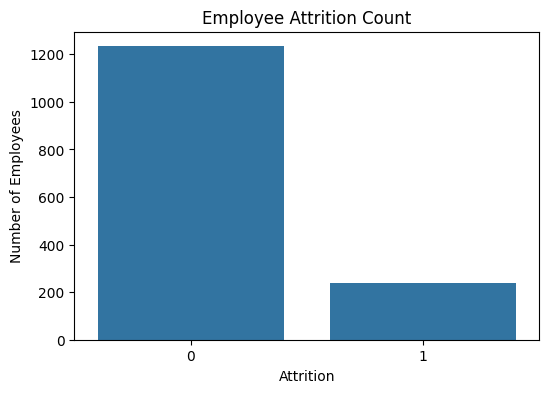

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Count")

plt.xlabel("Attrition")

plt.ylabel("Number of Employees")

plt.savefig("chart1.png")

plt.show()

### Observation

Most employees stayed in the company, while a smaller number left. This confirms that the dataset is imbalanced.

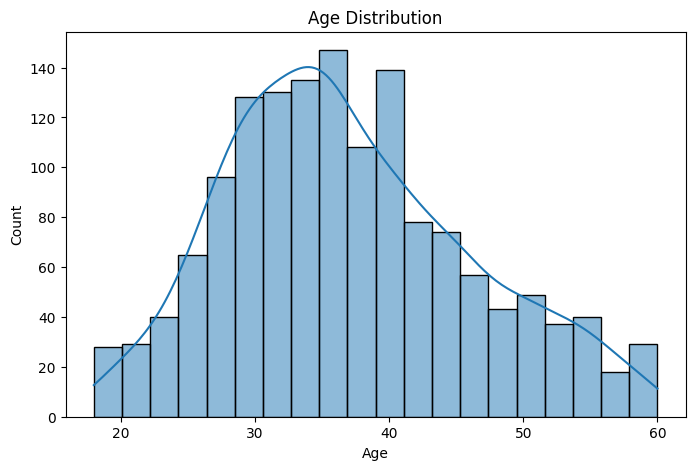

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.savefig("chart2.png")

plt.show()

### Observation

Most employees are between 30 and 40 years old, indicating that the workforce mainly consists of mid-career professionals.

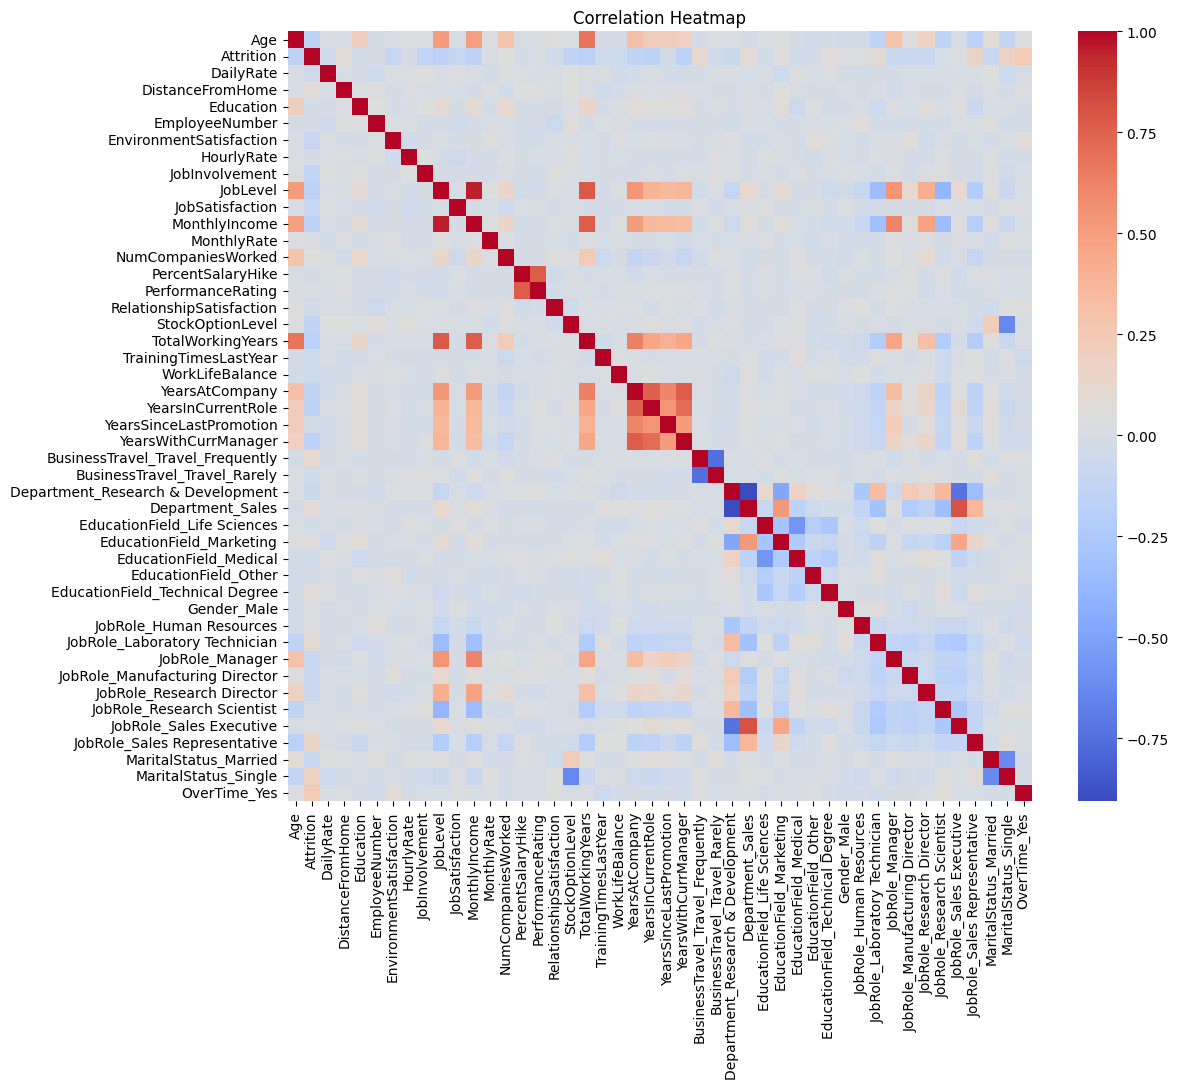

In [18]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("chart3.png")

plt.show()

### Observation

- The correlation heatmap shows that most features have weak correlations with each other.
- A few variables show moderate positive or negative relationships.
- No severe multicollinearity is observed, which is beneficial for machine learning models.

# Task 4: Model Building

In [19]:
# Separate input features and target variable

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 45)
(1470,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 45)
(294, 45)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Observation

- The dataset was divided into training and testing sets using an 80:20 ratio.
- Feature scaling was applied to improve model performance.
- The data is now ready for training machine learning models.

# Task 5: Machine Learning Models

In [22]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Task 6: Model Evaluation

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [26]:
print("===== Logistic Regression =====")

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy : 0.8605442176870748
Precision: 0.6153846153846154
Recall   : 0.3404255319148936
F1 Score : 0.4383561643835616


In [27]:
print("===== Decision Tree =====")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

===== Decision Tree =====
Accuracy : 0.7959183673469388
Precision: 0.3673469387755102
Recall   : 0.3829787234042553
F1 Score : 0.375


In [28]:
print("===== Random Forest =====")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

===== Random Forest =====
Accuracy : 0.8367346938775511
Precision: 0.46153846153846156
Recall   : 0.1276595744680851
F1 Score : 0.2


### **Observation**

* Logistic Regression achieved the best overall performance with an **accuracy of 86.05%**, making it the most effective model for predicting employee attrition.
* Decision Tree achieved lower accuracy but provided a slightly higher recall than Random Forest, identifying more employees who were likely to leave.
* Random Forest produced good accuracy but had a low recall, indicating that it missed many employees who actually left the company.
* Among all three models, Logistic Regression showed the best balance between accuracy and overall classification performance and was selected as the final model for employee attrition prediction.


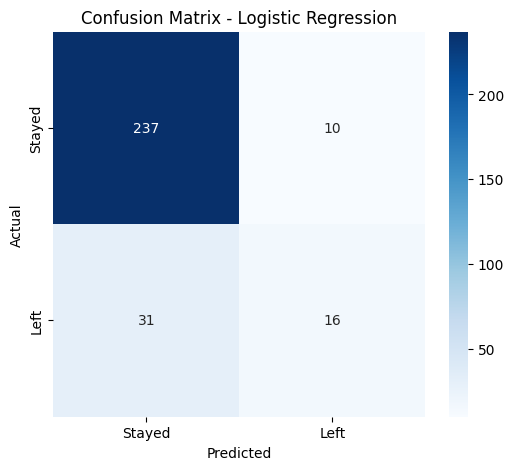

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Stayed","Left"],
            yticklabels=["Stayed","Left"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.savefig("chart4.png")

plt.show()

### **Conclusion**

* The employee attrition dataset was successfully cleaned and prepared for machine learning.
* Three classification models were trained and evaluated.
* Logistic Regression achieved the best overall performance with an accuracy of approximately 86%.
* The analysis shows that machine learning can effectively predict employee attrition and help organizations identify employees who may be at risk of leaving.